In [18]:
using Random
using PyPlot
using Statistics
using OrdinaryDiffEq
using LinearAlgebra

using Profile
using ProfileView

include("SuperradiantLasing/SuperradiantLasing.jl")
using .SuperradiantLasing

for n in names(SuperradiantLasing, all=true)
    @eval import .SuperradiantLasing: $(n)
end

include("SteadyState.jl")
using .SteadyState



In [19]:
function build_basis_naive(N::Int, S_samples, M_samples, pad::Int)
    S_abs_min = 0
    S_abs_max = N ÷ 2

    Smin = clamp(minimum(S_samples) - pad, S_abs_min, S_abs_max)
    Smax = clamp(maximum(S_samples) + pad, S_abs_min, S_abs_max)

    Mmin = minimum(M_samples) - pad
    Mmax = maximum(M_samples) + pad

    return [
        (S, M)
        for S in Smin:Smax
        for M in max(-S, Mmin):min(S, Mmax)
    ]
end

build_basis_naive (generic function with 1 method)

In [20]:
Δt_N(N) = 5.0 * 0.005 * 0.03 * (30000 / N) ^ 0.75

Δt_N (generic function with 1 method)

In [21]:
N = 20000
n_grid = 1500
N_traj = 10000
t_ss = Δt_N(N) * 8
r = 0.2 * N
rng = Xoshiro(1234)
pop_model = PopulationModel(N, N ÷ 2, 1.0, 0.0, 0.0, r, 0.0)

S_samples, M_samples = @time get_stationary_population_samples_ergodic(
    pop_model,
    N_traj;
    t_ss = t_ss,
    t_sample = t_ss * 3,
    S0 = pop_model.Jmax,
    M0 = -pop_model.Jmax,
    rng = rng,
)

params = Dict(
    "global_decay" => pop_model.global_decay,
    "global_pump" => pop_model.global_pump,
    "local_pump" => pop_model.local_pump,
    "local_decay" => pop_model.local_decay,
    "local_dephasing" => pop_model.local_dephasing,
)

pad = 50
max_J = max(maximum(S_samples), maximum(abs.(M_samples)))
Ω = build_basis_naive(N, S_samples, M_samples, pad)

basisΩ, idxΩ, RΩ, leakage = set_up_rate_matrix_on_basis(
    Ω, params, pop_model.Jmax;
    close_boundary = true,
)

p0 = population_from_samples(basisΩ, idxΩ, S_samples, M_samples)
p_ss = steady_by_implicit_euler(RΩ, p0; dt=1e3, nsteps=5)
diag = stationary_diagnostics(RΩ, p_ss; leakage=leakage)

  0.354184 seconds (132 allocations: 805.281 KiB)


LoadError: UndefVarError: `set_up_rate_matrix_on_basis` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

diag["mean_leakage"] = 2697.101319504746
diag["max_leakage"] = 4.2393855501466945e7
count(leakage .> 0) = 2620
pad = 50 n = 419520 residual = 9.017769660640463e-9 leakage = 2697.101319504746 meanS = 5999.853371510916 meanM = 2000.3624456433702 I = 3.1996294727546737e7


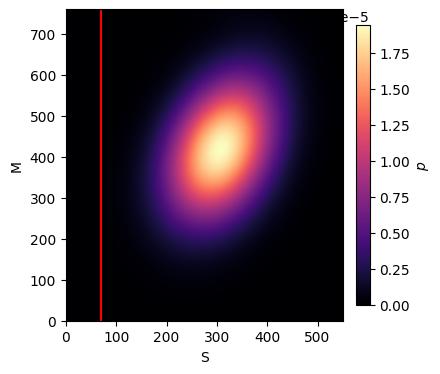

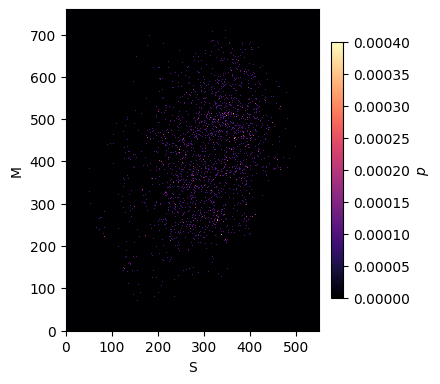

In [ ]:
@show diag["mean_leakage"]
@show diag["max_leakage"]
@show count(leakage .> 0)

plot_population_heatmap(basisΩ, p_ss; logscale=false)
axvline(sqrt(N)/2, color = "red")

figure()

plot_population_heatmap(basisΩ, p0; logscale=false)


Svals = first.(basisΩ)
Mvals = last.(basisΩ)

Imean = sum(p_ss[i] * (Svals[i] + Mvals[i]) * (Svals[i] - Mvals[i] + 1)
            for i in eachindex(p_ss))

println(
    "pad = ", pad,
    " n = ", length(Ω),
    " residual = ", norm(RΩ * p_ss, 1),
    " leakage = ", dot(leakage, p_ss),
    " meanS = ", dot(Svals, p_ss),
    " meanM = ", dot(Mvals, p_ss),
    " I = ", Imean,
)

In [ ]:
using DataStructures
using SparseArrays

function build_coherence_basis_naive(N::Int, S_samples, M_samples, pad::Int)
    Jmax = N ÷ 2

    Smin = clamp(minimum(S_samples) - pad, 0, Jmax)
    Smax = clamp(maximum(S_samples) + pad, 0, Jmax)

    Mmin = minimum(M_samples) - pad
    Mmax = maximum(M_samples) + pad

    basis = Tuple{Int,Int}[]

    for S in Smin:Smax
        # coherence state (S,M) means |S,M-1><S,M|,
        # so both M and M-1 must lie in [-S,S].
        lo = max(-S + 1, Mmin)
        hi = min( S,     Mmax)

        for M in lo:hi
            if valid_coherence_state(S, M, Jmax)
                push!(basis, (S, M))
            end
        end
    end

    return basis
end

function set_up_coherence_rate_matrix_on_basis(
    basis,
    params,
    Jmax;
    close_boundary::Bool = false,
)
    index_mapping = Dict(basis .=> eachindex(basis))

    sparse_constructor = DefaultDict{Tuple{Int,Int}, Float64}(0.0)
    leakage = zeros(Float64, length(basis))

    for state in basis
        i = index_mapping[state]

        internal, sink_rate = outgoing_for_coherence_state(state, params, Jmax)

        # The full outgoing decay of this coherence component.
        out_rate = sum(values(internal)) + sink_rate

        sparse_constructor[(i, i)] -= out_rate

        for (target, rate) in internal
            if haskey(index_mapping, target)
                j = index_mapping[target]
                sparse_constructor[(j, i)] += rate
            else
                leakage[i] += rate

                if close_boundary
                    # For coherence sectors I would usually NOT use this.
                    # But this option keeps the restricted norm from losing
                    # internal transfer probability/amplitude at the edge.
                    sparse_constructor[(i, i)] += rate
                end
            end
        end
    end

    I = Int[]
    J = Int[]
    V = Float64[]

    sizehint!(I, length(sparse_constructor))
    sizehint!(J, length(sparse_constructor))
    sizehint!(V, length(sparse_constructor))

    for ((i, j), v) in sparse_constructor
        push!(I, i)
        push!(J, j)
        push!(V, v)
    end

    n = length(basis)
    R = sparse(I, J, V, n, n)
    dropzeros!(R)

    return basis, index_mapping, R, leakage
end

function spectrum_from_coherence_generator(Rc, c0, readout, ωs)
    n = size(Rc, 1)
    Isp = spdiagm(0 => ones(ComplexF64, n))

    c0c = ComplexF64.(c0)
    vc = ComplexF64.(readout)

    Sω = similar(ωs, Float64)

    for (k, ω) in pairs(ωs)
        @show k
        A = ComplexF64.(Rc) + im * ω * Isp
        x = A \ c0c
        Sω[k] = -2 * real(dot(vc, x))
    end

    return Sω
end
function spectrum_sparse_lu(Rc, c0, readout, ωs)
    n = size(Rc, 1)

    Rc_c = ComplexF64.(Rc)
    c0c = ComplexF64.(c0)
    v = ComplexF64.(readout)
    Isp = spdiagm(0 => ones(ComplexF64, n))

    Sω = zeros(Float64, length(ωs))

    for (k, ω) in pairs(ωs)
        @show k
        Aω = Rc_c + im * ω * Isp
        F = lu(Aω)

        x = F \ c0c
        Sω[k] = -2 * real(sum(v .* x))
    end

    return Sω
end

pad = 50

Ωc = build_coherence_basis_naive(N, S_samples, M_samples, pad)
basisΩc, idxΩc, Rc, leakage_c = set_up_coherence_rate_matrix_on_basis(Ωc, params, pop_model.Jmax; close_boundary = false)
c0 = coherence_initial_from_population_ss(basisΩ, p_ss, idxΩc)
readout = coherence_readout_vector(basisΩc)

419520-element Vector{Float64}:
 5469.44238474088
 5469.153133712751
 5468.863684532647
 5468.5740371691045
 5468.284191590631
 5467.994147765705
 5467.703905662778
 5467.4134652502735
 5467.122826496584
 5466.831989370077
 5466.540953839091
 5466.249719871934
 5465.958287436888
    ⋮
 5793.721601872151
 5793.3194284451465
 5792.917054472643
 5792.514479912847
 5792.111704723934
 5791.708728864048
 5791.305552291296
 5790.9021749637595
 5790.498596839481
 5790.094817876474
 5789.690838032719
 5789.286657266161

In [29]:
@time spectrum_from_coherence_generator(Rc, c0, readout, [0.0])

k = 1
 20.511270 seconds (3.43 M allocations: 1.778 GiB, 9.13% gc time, 20.10% compilation time)


1-element Vector{Float64}:
 973127.1319161918

In [31]:
diag(Rc)

LoadError: MethodError: no method matching diagm(::SparseMatrixCSC{Float64, Int64})
The function `diagm` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  diagm([91m::Pair{<:Val, <:StaticArraysCore.StaticArray{Tuple{N}, T, 1} where {N, T}}[39m, Pair{<:Val, <:StaticArraysCore.StaticArray{Tuple{N}, T, 1} where {N, T}}...)
[0m[90m   @[39m [33mStaticArrays[39m [90m~/.julia/packages/StaticArrays/0cEwi/src/[39m[90m[4mlinalg.jl:205[24m[39m
[0m  diagm([91m::Pair{<:Integer, <:AbstractVector}...[39m)
[0m[90m   @[39m [32mLinearAlgebra[39m [90m~/.julia/juliaup/julia-1.12.5+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/LinearAlgebra/src/[39m[90m[4mdense.jl:367[24m[39m
[0m  diagm([91m::StaticArraysCore.StaticArray{Tuple{N}, T, 1} where {N, T}[39m)
[0m[90m   @[39m [33mStaticArrays[39m [90m~/.julia/packages/StaticArrays/0cEwi/src/[39m[90m[4mlinalg.jl:227[24m[39

In [4]:
using DifferentialEquations
using LinearAlgebra
using PyPlot

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

Base.@kwdef struct LasingMFParams
    N::Float64 = 1e4
    γ::Float64 = 0.0
    κ::Float64 = 10.0
    g::Float64 = 1e-2
    R::Float64 = 1e-3
    ϵ::ComplexF64 = 1e-8 + 0im
end

Γ_eff(p::LasingMFParams) = 4 * p.g^2 / p.κ

# ------------------------------------------------------------
# Full cavity mean field
# u = [α_re, α_im, s_re, s_im, sz]
# ------------------------------------------------------------

function lasing_full_mf!(du, u, p::LasingMFParams, t)
    α = u[1] + im * u[2]
    s = u[3] + im * u[4]
    sz = u[5]

    dα = -p.κ / 2 * α - im * p.g * s + p.ϵ
    ds = -(p.γ + p.R) / 2 * s + 2im * p.g * α * sz
    dsz = -(p.γ + p.R) * sz +
          im * p.g * (conj(α) * s - α * conj(s)) +
          p.N * (p.R - p.γ) / 2

    du[1] = real(dα)
    du[2] = imag(dα)
    du[3] = real(ds)
    du[4] = imag(ds)
    du[5] = real(dsz)

    return nothing
end

# ------------------------------------------------------------
# Bad-cavity mean field
# u = [s_re, s_im, sz]
# ------------------------------------------------------------

function lasing_badcavity_mf!(du, u, p::LasingMFParams, t)
    s = u[1] + im * u[2]
    sz = u[3]

    Γ = Γ_eff(p)
    α = 2 / p.κ * (p.ϵ - im * p.g * s)

    ds = -(p.γ + p.R) / 2 * s + 2im * p.g * α * sz
    dsz = -(p.γ + p.R) * sz +
          im * p.g * (conj(α) * s - α * conj(s)) +
          p.N * (p.R - p.γ) / 2

    du[1] = real(ds)
    du[2] = imag(ds)
    du[3] = real(dsz)

    return nothing
end

# ------------------------------------------------------------
# Solvers
# ------------------------------------------------------------

function solve_full_mf(p::LasingMFParams; tmax=2e5)
    u0 = [
        0.0, 0.0,        # α
        0.0, 0.0,        # s
        -p.N / 2         # sz
    ]

    prob = ODEProblem(lasing_full_mf!, u0, (0.0, tmax), p)
    solve(prob, Rodas5P(); reltol=1e-14, abstol=1e-14, saveat=ts)
end

function solve_badcavity_mf(p::LasingMFParams; tmax=2e5)
    u0 = [
        0.0, 0.0,        # s
        -p.N / 2         # sz
    ]

    prob = ODEProblem(lasing_badcavity_mf!, u0, (0.0, tmax), p)
    solve(prob, Rodas5P(); reltol=1e-14, abstol=1e-14, saveat=ts)
end

# ------------------------------------------------------------
# Observables
# ------------------------------------------------------------

function obs_full(sol, p::LasingMFParams, ts)
    α = ComplexF64[]
    s = ComplexF64[]
    sz = Float64[]

    for t in ts
        u = sol(t)
        push!(α, u[1] + im * u[2])
        push!(s, u[3] + im * u[4])
        push!(sz, u[5])
    end

    return (; α, s, sz, nph=abs2.(α), coh=abs2.(s))
end

function obs_badcavity(sol, p::LasingMFParams, ts)
    s = ComplexF64[]
    sz = Float64[]
    α = ComplexF64[]

    for t in ts
        u = sol(t)
        st = u[1] + im * u[2]
        push!(s, st)
        push!(sz, u[3])
        push!(α, 2 / p.κ * (p.ϵ - im * p.g * st))
    end|

    return (; α, s, sz, nph=abs2.(α), coh=abs2.(s))
end

obs_badcavity (generic function with 1 method)

In [5]:
function run_mf_comparison(p; tmax=5000.0, nt=2000)
    ts = range(0.0, tmax, length=nt)

    sol_full = solve_full_mf(p; tmax=tmax)
    sol_bad = solve_badcavity_mf(p; tmax=tmax)

    of = obs_full(sol_full, p, ts)
    ob = obs_badcavity(sol_bad, p, ts)

    return (; ts, sol_full, sol_bad, of, ob)
end

function make_badcavity_params(; N, g, κ, r_over_Γ, γ=0.0, ϵ=1e-8+0im)
    Γ = 4 * g^2 / κ
    R = r_over_Γ * Γ

    return LasingMFParams(
        N = float(N),
        γ = float(γ),
        κ = float(κ),
        g = float(g),
        R = float(R),
        ϵ = ComplexF64(ϵ),
    )
end

p = LasingMFParams(
    N = 1e4,
    γ = 0.0,
    κ = 10.0,
    g = 1e-2,
    R = 1.8e-5,
    ϵ = 1e-6 + 0im,
)
@show 4 * p.g^2 / p.κ
@show p.R/(4 * p.g^2 / p.κ)

sol = run_mf_comparison(p; tmax = 320000.0, nt = 100000)
plot(sol.ts, sol.of.nph)
plot(sol.ts, sol.ob.nph)

figure()
plot(sol.ts, sol.of.s)
plot(sol.ts, sol.ob.s)
ylim(bottom = -20, top = 20)

(4 * p.g ^ 2) / p.κ = 4.0e-5
p.R / ((4 * p.g ^ 2) / p.κ) = 0.44999999999999996


LoadError: UndefVarError: `ts` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
function make_badcavity_params_collective(; N, g, κ, r, η=0.0, ϵ=1e-8+0im)
    Γ = 4 * g^2 / κ
    R = r * N * Γ
    γ = η * N * Γ

    return LasingMFParams(
        N = float(N),
        γ = float(γ),
        κ = float(κ),
        g = float(g),
        R = float(R),
        ϵ = ComplexF64(ϵ),
    )
end

function bad_cavity_intensive_mf!(du, u, p, τ)
    y = u[1]   # |s|^2 / N^2
    m = u[2]   # sz / N

    Γ = Γ_eff(p)
    r = p.R / (p.N * Γ)
    η = p.γ / (p.N * Γ)

    du[1] = (2m - r - η) * y
    du[2] = -(r + η) * m - y + (r - η) / 2

    return nothing
end

function solve_bad_cavity_intensive(p; τmax=100.0, nt=50000, y0=1e-16, m0=-0.5)
    τs = collect(range(0.0, τmax, length=nt))
    u0 = [y0, m0]

    prob = ODEProblem(bad_cavity_intensive_mf!, u0, (0.0, τmax), p)

    sol = solve(prob, Rodas5P();
        reltol = 1e-10,
        abstol = 1e-12,
        saveat = τs
    )

    y = [u[1] for u in sol.u]
    m = [u[2] for u in sol.u]

    return (; τs, ts=τs ./ (p.N * Γ_eff(p)), sol, y, m)
end

solve_bad_cavity_intensive (generic function with 1 method)

Γ = 4.0e-5
p.R / Γ = 0.75
p.R / (p.N * Γ) = 7.5e-5


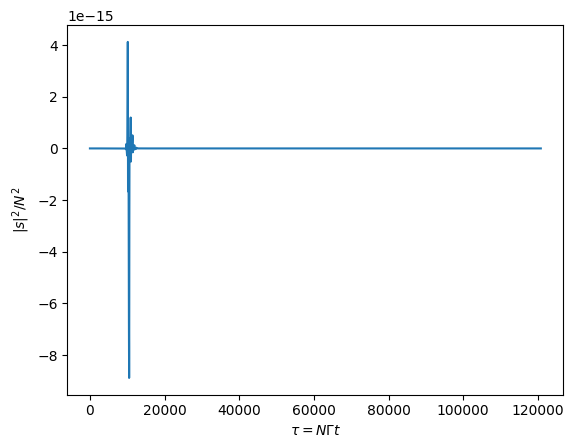

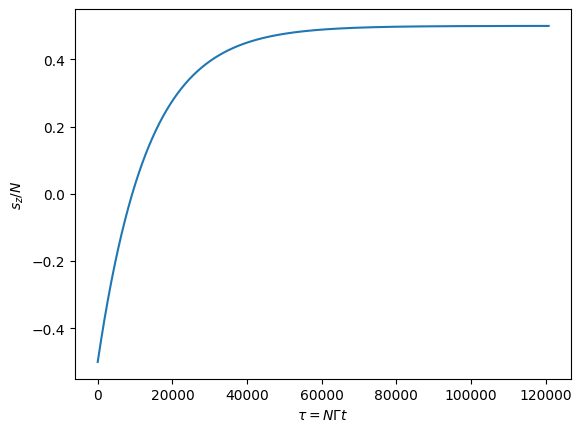

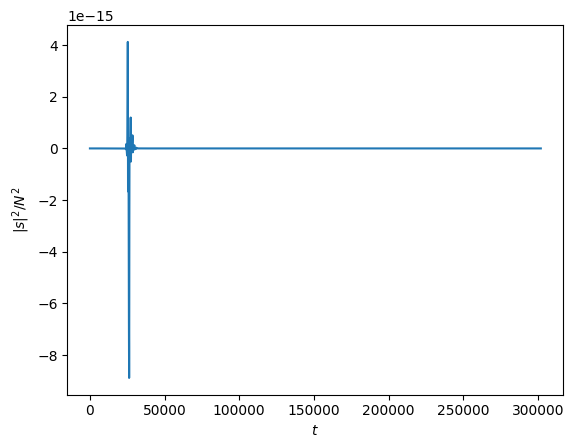

PyObject Text(31.600000000000016, 0.5, '$|s|^2/N^2$')

In [ ]:
p = LasingMFParams(
    N = 1e4,
    γ = 0.0,
    κ = 10.0,
    g = 1e-2,
    R = 3.0e-5,
    ϵ = 1e-6 + 0im,
)

Γ = Γ_eff(p)

@show Γ
@show p.R / Γ
@show p.R / (p.N * Γ)

tmax = 3_020_00
nt = 100_000

Γ = Γ_eff(p)
τmax = p.N * Γ * tmax

bad = solve_bad_cavity_intensive(
    p;
    τmax = τmax,
    nt = nt,
    y0 = abs2(p.ϵ) / p.N^2,
    m0 = -0.5,
)

figure()
plot(bad.τs, bad.y)
xlabel(L"\tau = N\Gamma t")
ylabel(L"|s|^2/N^2")

figure()
plot(bad.τs, bad.m)
xlabel(L"\tau = N\Gamma t")
ylabel(L"s_z/N")

figure()
plot(bad.ts, bad.y)
xlabel(L"t")
ylabel(L"|s|^2/N^2")

In [8]:
function bad_cavity_log_intensive_mf!(du, u, p, τ)
    ℓ = u[1]
    m = u[2]

    Γ = Γ_eff(p)
    r = p.R / (p.N * Γ)
    η = p.γ / (p.N * Γ)

    y = exp(ℓ)

    du[1] = 2m - r - η
    du[2] = -(r + η) * m - y + (r - η) / 2

    return nothing
end

function solve_bad_cavity_log_intensive(p; tmax, nt=100000, y0=1e-30, m0=-0.5)
    Γ = Γ_eff(p)
    τmax = p.N * Γ * tmax
    τs = collect(range(0.0, τmax, length=nt))

    u0 = [log(y0), m0]
    prob = ODEProblem(bad_cavity_log_intensive_mf!, u0, (0.0, τmax), p)

    sol = solve(prob, Vern9();
        reltol = 1e-13,
        abstol = 1e-13,
        saveat = τs
    )

    ℓ = [u[1] for u in sol.u]
    m = [u[2] for u in sol.u]
    y = exp.(ℓ)

    return (; ts = τs ./ (p.N * Γ), τs, sol, ℓ, y, m)
end

function lasing_full_log_real_mf!(du, u, p, t)
    a = u[1]       # α = i a
    ℓ = u[2]       # log(s^2)
    m = u[3]

    s = exp(ℓ/2)

    du[1] = -p.κ/2 * a - p.g * s + real(p.ϵ)
    ds = -(p.R + p.γ)/2 * s - 2*p.g * a * m

    du[2] = 2 * ds / s
    du[3] = -(p.R + p.γ)*m + 2*p.g*a*s + p.N*(p.R - p.γ)/2

    return nothing
end

function solve_full_log_real_mf(p; tmax, nt=100000, s0=1e-15, a0=0.0, m0=-p.N/2)
    ts = collect(range(0.0, tmax, length=nt))

    u0 = [a0, log(s0^2), m0]

    prob = ODEProblem(lasing_full_log_real_mf!, u0, (0.0, tmax), p)

    sol = solve(prob, Tsit5();
        reltol = 1e-11,
        abstol = 1e-13,
        saveat = ts
    )

    a = [u[1] for u in sol.u]
    ℓ = [u[2] for u in sol.u]
    m = [u[3] for u in sol.u]

    s = exp.(ℓ ./ 2)

    return (; ts, sol, a, s, m,
            nph = a.^2,
            coh = s.^2)
end

solve_full_log_real_mf (generic function with 1 method)

p.R / ((4 * p.g ^ 2) / p.κ) = 0.5
bad.m[end] = 2.499999980009355e-5


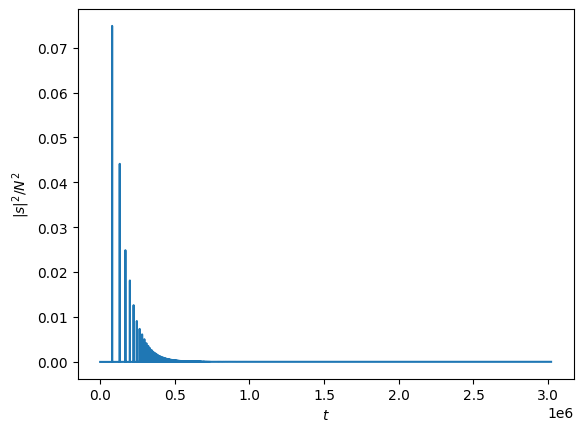

bad.y[end] = 2.4998750000526812e-5


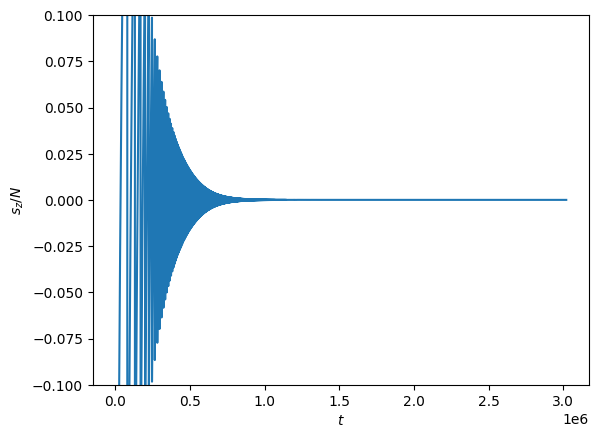

2.4998750000526812e-5

In [ ]:
p = LasingMFParams(
    N = 1e4,
    γ = 0.0,
    κ = 10.0,
    g = 1e-2,
    R = 2e-5,
    ϵ = 1e-4 + 0im,
)

@show p.R / (4 * p.g ^ 2 / p.κ)

bad = solve_bad_cavity_log_intensive(
    p;
    tmax = 3_020_000.0,
    nt = 100_000,
    y0 = 1e-30,
    m0 = -0.5,
)

figure()
plot(bad.ts, bad.y)
xlabel(L"t")
ylabel(L"|s|^2/N^2")

figure()
plot(bad.ts, bad.m)
xlabel(L"t")
ylabel(L"s_z/N")
ylim(-0.1, 0.1)
@show bad.m[end]
@show bad.y[end]

In [ ]:
full = solve_full_log_real_mf(
    p;
    tmax = 3_020_00.0,
    nt = 100_000,
    s0 = 1e-15,
    a0 = 0.0,
    m0 = -p.N/2,
)

(ts = [0.0, 3.020030200302003, 6.040060400604006, 9.060090600906008, 12.080120801208013, 15.100151001510016, 18.120181201812017, 21.140211402114023, 24.160241602416026, 27.18027180271803  …  301972.8197281973, 301975.8397583976, 301978.8597885979, 301981.87981879816, 301984.89984899847, 301987.9198791988, 301990.9399093991, 301993.9599395994, 301996.9799697997, 302000.0], sol = ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{Float64}}}, Nothing, ODEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, LasingMFParams, ODEFunction{true, SciMLBase.AutoSpecialize, FunctionWrappersWrappers.FunctionWrappersWrapper{Tuple{FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{Float64}, Vector{Float64}, LasingMFParams, Float64}}}, false}, UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing, Nothing, Nothing}

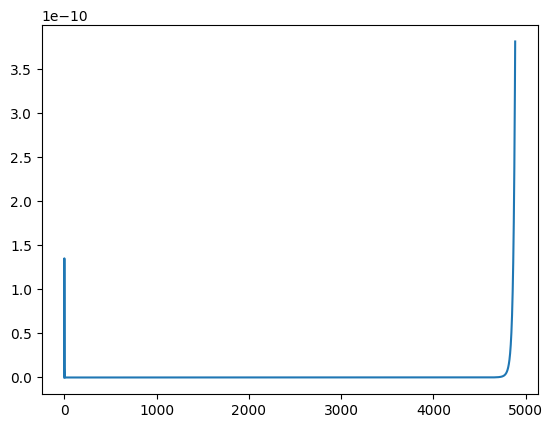

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x3d3e297f0>

In [ ]:
plot(abs.(full.nph))

In [ ]:
figure()
plot(full.ts, full.nph)

figure()
plot(full.ts, full.m)
ylim(-20, 20)

figure()
plot(full.ts, full.s)

LoadError: PyError ($(Expr(:escape, :(ccall(#= /Users/nicobassler/.julia/packages/PyCall/1gn3u/src/pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'ValueError'>
ValueError('x and y must have same first dimension, but have shapes (100000,) and (15880,)')
  File "/Users/nicobassler/.pyenv/versions/loc/lib/python3.14/site-packages/matplotlib/pyplot.py", line 3838, in plot
    return gca().plot(
           ~~~~~~~~~~^
        *args,
        ^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/nicobassler/.pyenv/versions/loc/lib/python3.14/site-packages/matplotlib/axes/_axes.py", line 1777, in plot
    lines = [*self._get_lines(self, *args, data=data, **kwargs)]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nicobassler/.pyenv/versions/loc/lib/python3.14/site-packages/matplotlib/axes/_base.py", line 297, in __call__
    yield from self._plot_args(
               ~~~~~~~

Γ = 4.0e-5
p_mf.R / Γ = 0.8
p_mf.R / (p_mf.N * Γ) = 4.0e-5
diag["mean_leakage"] = 0.000151598144702243
diag["max_leakage"] = 7694.4
count(leakage .> 0) = 765
norm(RΩ * p_ss, 1) = 2.5707205129792305e-12
dot(leakage, p_ss) = 0.000151598144702243
m_exact = -9.35097981043868e-6
y_exact = 2.000037366019705e-5
bad.m[end] = 1.9999999997824662e-5
bad.y[end] = 1.999920000000056e-5


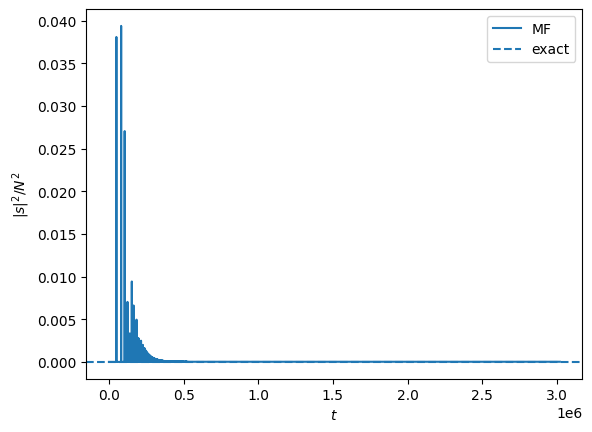

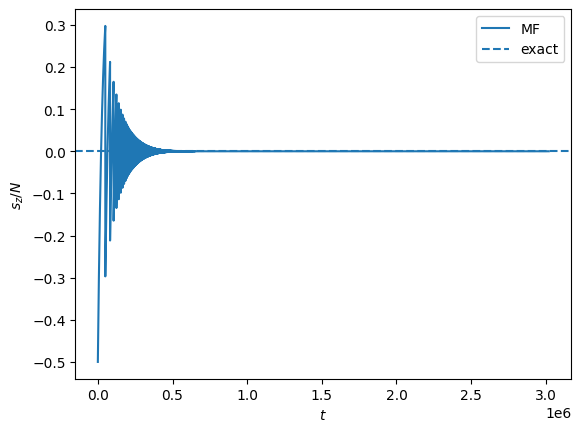

(exact = (-9.35097981043868e-6, 2.000037366019705e-5), mf = (ts = [0.0, 30.20030200302003, 60.40060400604006, 90.60090600906008, 120.80120801208012, 151.00151001510014, 181.20181201812017, 211.40211402114022, 241.60241602416025, 271.8027180271803  …  3.019728197281973e6, 3.019758397583976e6, 3.019788597885979e6, 3.0198187981879814e6, 3.0198489984899843e6, 3.0198791987919877e6, 3.0199093990939907e6, 3.0199395993959936e6, 3.0199697996979966e6, 3.02e6], τs = [0.0, 24.160241602416026, 48.32048320483205, 72.48072480724807, 96.6409664096641, 120.80120801208012, 144.96144961449613, 169.12169121691218, 193.2819328193282, 217.44217442174423  …  2.4157825578255784e6, 2.415806718067181e6, 2.4158308783087833e6, 2.4158550385503853e6, 2.4158791987919877e6, 2.41590335903359e6, 2.4159275192751926e6, 2.415951679516795e6, 2.4159758397583975e6, 2.416e6], sol = ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{Float64}}}, Nothing, ODEProblem{Vector{Fl

In [10]:
function compare_exact_vs_bad_mf(;
    # exact (MC / PI) controls
    N = 20_000,
    N_traj = 100_000,
    t_ss_exact = 800.0,
    t_sample_factor = 3.0,
    pad = 50,
    seed = 1234,
    dt_implicit = 1e3,
    nsteps_implicit = 5,
    r = 0.5,                  # means R/Γ

    # physical parameters (keep external)
    g = 1e-2,
    κ = 10.0,
    γ = 0.0,
    ϵ = 1e-4 + 0im,

    # MF controls (physical time)
    tmax_mf = 3_020_000.0,
    nt_mf = 100_000,
    y0_mf = 1e-30,
)
    rng = Xoshiro(seed)

    # ----------------------------
    # Exact (MC support + PI SS)
    # ----------------------------
    pop_model = PopulationModel(N, N ÷ 2, 1.0, 0.0, 0.0, r, 0.0)

    S_samples, M_samples = get_stationary_population_samples_ergodic(
        pop_model,
        N_traj;
        t_ss = t_ss_exact,
        t_sample = t_ss_exact * t_sample_factor,
        S0 = pop_model.Jmax,
        M0 = -pop_model.Jmax,
        rng = rng,
    )

    params = Dict(
        "global_decay" => pop_model.global_decay,
        "global_pump" => pop_model.global_pump,
        "local_pump" => pop_model.local_pump,
        "local_decay" => pop_model.local_decay,
        "local_dephasing" => pop_model.local_dephasing,
    )

    max_J = max(maximum(S_samples), maximum(abs.(M_samples)))
    Ω = build_basis(max_J + pad)

    basisΩ, idxΩ, RΩ, leakage = set_up_rate_matrix_on_basis(
        Ω, params, pop_model.Jmax; close_boundary = true
    )

    p0 = population_from_samples(basisΩ, idxΩ, S_samples, M_samples)
    p_ss = steady_by_implicit_euler(RΩ, p0; dt=dt_implicit, nsteps=nsteps_implicit)
    diag = stationary_diagnostics(RΩ, p_ss; leakage=leakage)

    Svals = Float64.(first.(basisΩ))
    Mvals = Float64.(last.(basisΩ))
    SpSm_vals = (Svals .+ Mvals) .* (Svals .- Mvals .+ 1)

    S_exact = dot(Svals, p_ss)
    M_exact = dot(Mvals, p_ss)
    I_exact = dot(SpSm_vals, p_ss)

    m_exact = M_exact / N
    y_exact = I_exact / N^2

    # ----------------------------
    # MF with same physical params
    # ----------------------------
    Γ = 4 * g^2 / κ

    p_mf = LasingMFParams(
        N = Float64(N),
        γ = γ,
        κ = κ,
        g = g,
        R = r * Γ,      # <-- only mapping you need
        ϵ = ϵ,
    )

    @show Γ
    @show p_mf.R / Γ           # should be r
    @show p_mf.R / (p_mf.N*Γ)  # internal MF parameter

    bad = solve_bad_cavity_log_intensive(
        p_mf;
        tmax = tmax_mf,
        nt = nt_mf,
        y0 = y0_mf,
        m0 = -0.5,
    )

    # ----------------------------
    # Compare
    # ----------------------------
    @show diag["mean_leakage"] diag["max_leakage"] count(leakage .> 0)
    @show norm(RΩ * p_ss, 1) dot(leakage, p_ss)

    @show m_exact y_exact
    @show bad.m[end] bad.y[end]

    figure()
    plot(bad.ts, bad.y, label="MF")
    axhline(y_exact, linestyle="--", label="exact")
    xlabel(L"t"); ylabel(L"|s|^2/N^2"); legend()

    figure()
    plot(bad.ts, bad.m, label="MF")
    axhline(m_exact, linestyle="--", label="exact")
    xlabel(L"t"); ylabel(L"s_z/N"); legend()

    return (; exact=(m_exact,y_exact), mf=bad)
end
res = compare_exact_vs_bad_mf(
    N = 20_000,
    N_traj = 100_000,
    t_ss_exact = 2000.0,
    r = 0.8,
    tmax_mf = 3_020_000.0,
)

Γ = 4.0e-5
p_mf.R / Γ = 20.0
p_mf.R / (p_mf.N * Γ) = 0.001
diag["mean_leakage"] = 0.07882759791330066
diag["max_leakage"] = 180480.0
count(leakage .> 0) = 1953
norm(RΩ * p_ss, 1) = 6.09987742822029e-11
dot(leakage, p_ss) = 0.07882759791330066
m_exact = 0.000525002822787138
y_exact = 0.0004994748001082183
bad.m[end] = 0.0004999990690797748
bad.y[end] = 0.0004995000972544784


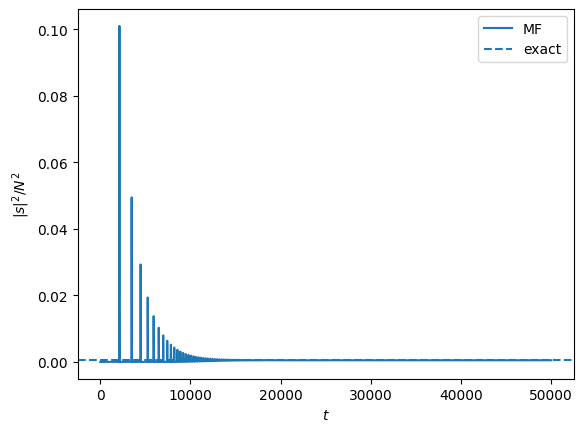

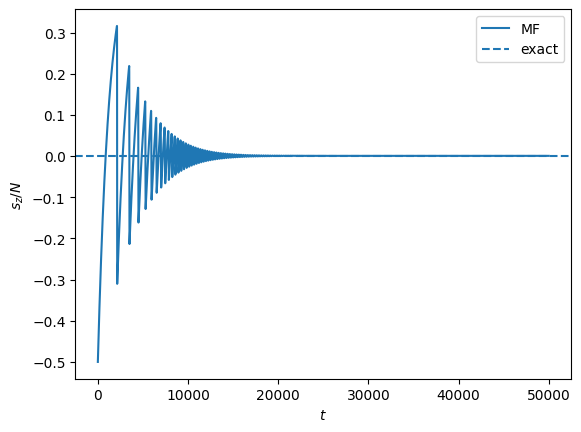

(exact = (0.000525002822787138, 0.0004994748001082183), mf = (ts = [0.0, 0.5000050000500005, 1.000010000100001, 1.5000150001500014, 2.000020000200002, 2.500025000250002, 3.000030000300003, 3.5000350003500036, 4.000040000400004, 4.5000450004500046  …  49995.49995499955, 49995.99995999959, 49996.499964999646, 49996.99996999969, 49997.499974999744, 49997.999979999804, 49998.49998499985, 49998.9999899999, 49999.49999499995, 50000.0], τs = [0.0, 0.4000040000400004, 0.8000080000800008, 1.2000120001200012, 1.6000160001600017, 2.000020000200002, 2.4000240002400024, 2.800028000280003, 3.2000320003200033, 3.600036000360004  …  39996.39996399964, 39996.79996799968, 39997.19997199972, 39997.59997599976, 39997.9999799998, 39998.39998399984, 39998.79998799988, 39999.19999199992, 39999.59999599996, 40000.0], sol = ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{Float64}}}, Nothing, ODEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, Lasi

In [15]:
res = compare_exact_vs_bad_mf(
    N = 20_000,
    N_traj = 100_000,
    t_ss_exact = 200.0,
    r = 20.0,
    tmax_mf = 50000.0,
)

# Check the pump thing for finite N